# Progetto di Cavallari Anna matr. 1099291 e Gobbo Chiara matr.1096072

## ANALISI SU DATASET AI JOB RECCOMENDATION 
- preprocessing
- distribuzione delle variabili
- clustering

___
## importazione librerie

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from sklearn.datasets import load_iris                 non serve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from scipy.stats import chi2_contingency

print('Librerie caricate correttamente.') 

Librerie caricate correttamente.


___
## Caricamento dati:

In [43]:
file_path = "ds/job_recommendation_dataset.csv"
df = pd.read_csv(file_path)
print(f"Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne")

Dataset caricato: 50,000 righe × 7 colonne


___
## Controllo parte iniziale del dataset, prime 5 righe e le informazioni su di esso:

In [44]:
print(df.head())
print(df.info())

                         Job Title                      Company  \
0              Early years teacher               Richardson Ltd   
1         Counselling psychologist  Ramos, Santiago and Stewart   
2        Radio broadcast assistant                 Franco Group   
3     Designer, exhibition/display                  Collins Inc   
4  Psychotherapist, dance movement                 Barker Group   

        Location Experience Level    Salary    Industry  \
0         Sydney     Senior Level   87000.0  Healthcare   
1  San Francisco        Mid Level   50000.0   Marketing   
2       New York        Mid Level   77000.0  Healthcare   
3         Berlin     Senior Level   90000.0    Software   
4         Sydney      Entry Level  112000.0  Healthcare   

                                     Required Skills  
0                                    Pharmaceuticals  
1                   Google Ads, SEO, Content Writing  
2  Patient Care, Nursing, Medical Research, Pharm...  
3                     

___
## Controllo missing nel dataset:

In [45]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)


if missing.empty:
    print('Nessun valore mancante nel dataset!')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))


Nessun valore mancante nel dataset!


### Stampa delle variabili categoriali presenti:

In [46]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (6): ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']


___
## informazioni utili sul dataset

In [47]:
df.info()
df.shape
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  str    
 1   Company           50000 non-null  str    
 2   Location          50000 non-null  str    
 3   Experience Level  50000 non-null  str    
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  str    
 6   Required Skills   50000 non-null  str    
dtypes: float64(1), str(6)
memory usage: 2.7 MB


Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

In [48]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Experience Level', 'Salary',
       'Industry', 'Required Skills'],
      dtype='str')

___
## box plot

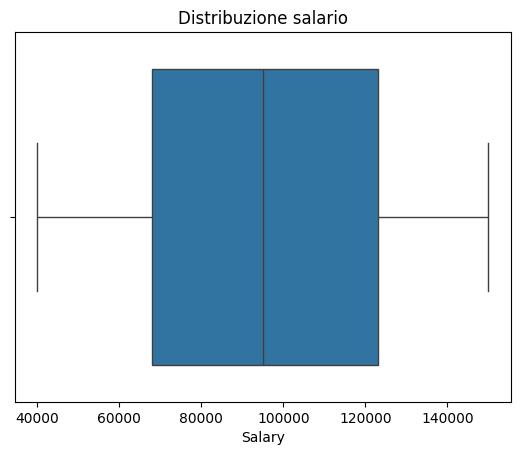

In [49]:
sns.boxplot(x=df['Salary'])
plt.title("Distribuzione salario")
plt.show()

### borx plot di confronto delle variabili
- salario rispetto al livello di educazione

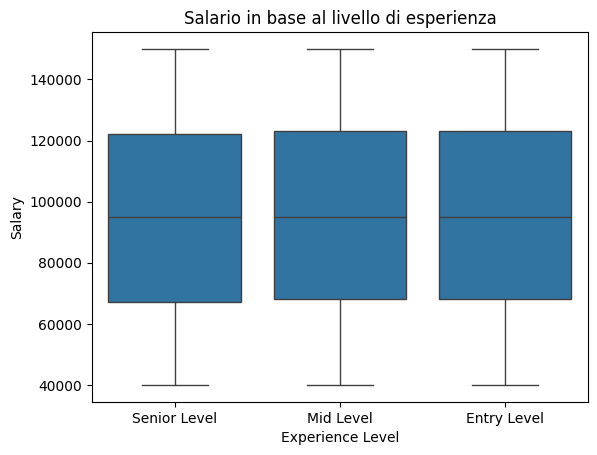

In [50]:
sns.boxplot(x='Experience Level', y='Salary', data=df)
plt.title("Salario in base al livello di esperienza")
plt.show()

Dal box plot si osserva che il salario non varia significativamente tra i diversi livelli di esperienza.
Questo potrebbe indicare che nel dataset non esiste una forte relazione tra esperienza e salario, oppure che i dati sono distribuiti in modo uniforme.

### salario rispetto alla città:

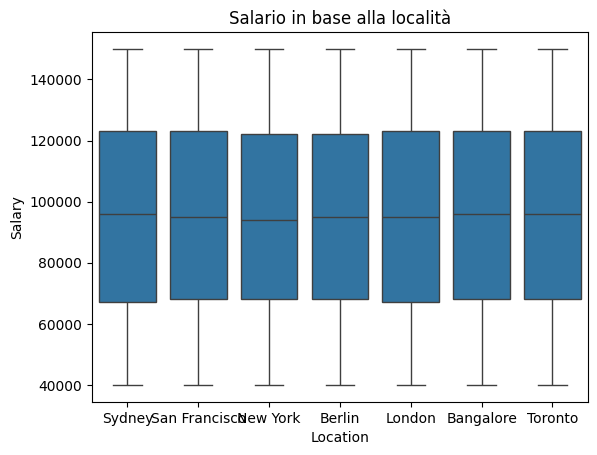

In [51]:
sns.boxplot(x='Location', y='Salary', data=df)
plt.title("Salario in base alla località")
plt.show()

possiamo notare che anche in questo caso non ci son delle differenze rilevanti ma minime, ad esempio per new york possiamo notare che il terzo quartile tocca un livello di salario più basso rispetto alle altre città, mentre Bangalore il suo primo quartile parte da un livello di salario base più alto. La mediana più alta si trova in Bangalore

### salario rispetto al settore di lavoro:

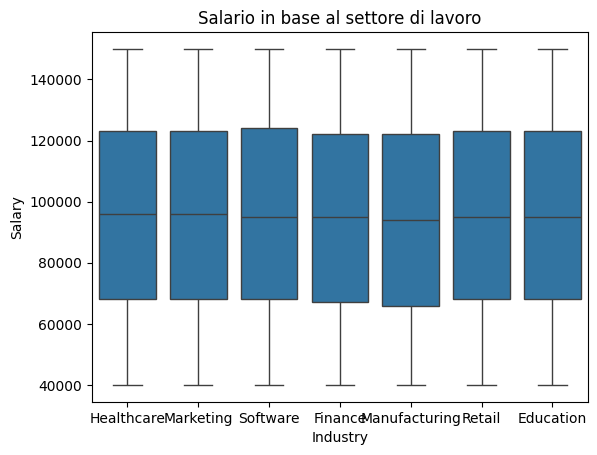

In [52]:
sns.boxplot(x='Industry', y='Salary', data=df)
plt.title("Salario in base al settore di lavoro")
plt.show()

osservando questo boxplot possiamo notare che il settore manufatturiero è quello con la retribuzion più bassa generalmente, si può notare da media, mediana e l'interquartilico. 

Colonne numeriche: ['Salary']


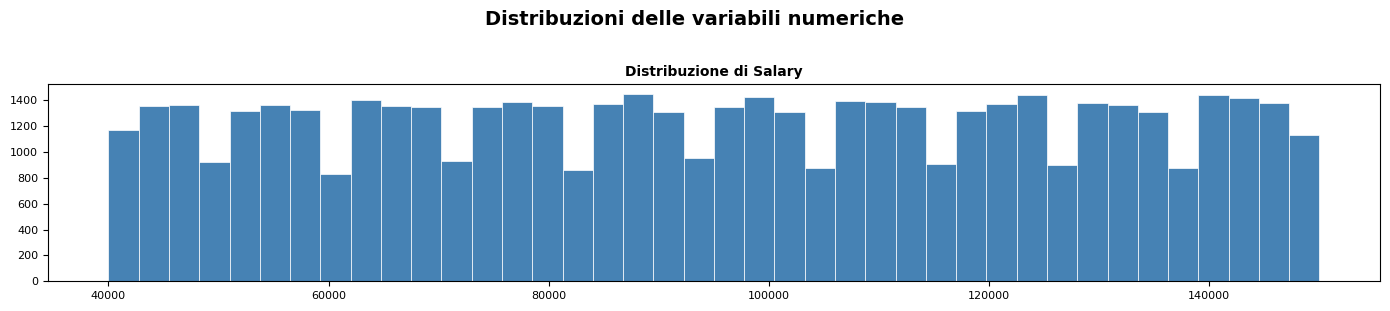

In [53]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Colonne numeriche:", num_cols)

# Numero di feature numeriche
n = len(num_cols)

# Numero di righe necessarie
nrows = (n + 1 - 1) // 1 # 1 perchè cè' solo una colonna numerica

# Crea figura e assi
fig, axes = plt.subplots(nrows, 1, figsize=(14, nrows * 3))
axes = np.array(axes).reshape(-1)
axes = axes.flatten()

# Istogrammi
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

# Nasconde gli assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni delle variabili numeriche',
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### Variabili categoriche:

In [54]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
Company,37022
Required Skills,1559
Job Title,639
Location,7
Industry,7
Experience Level,3


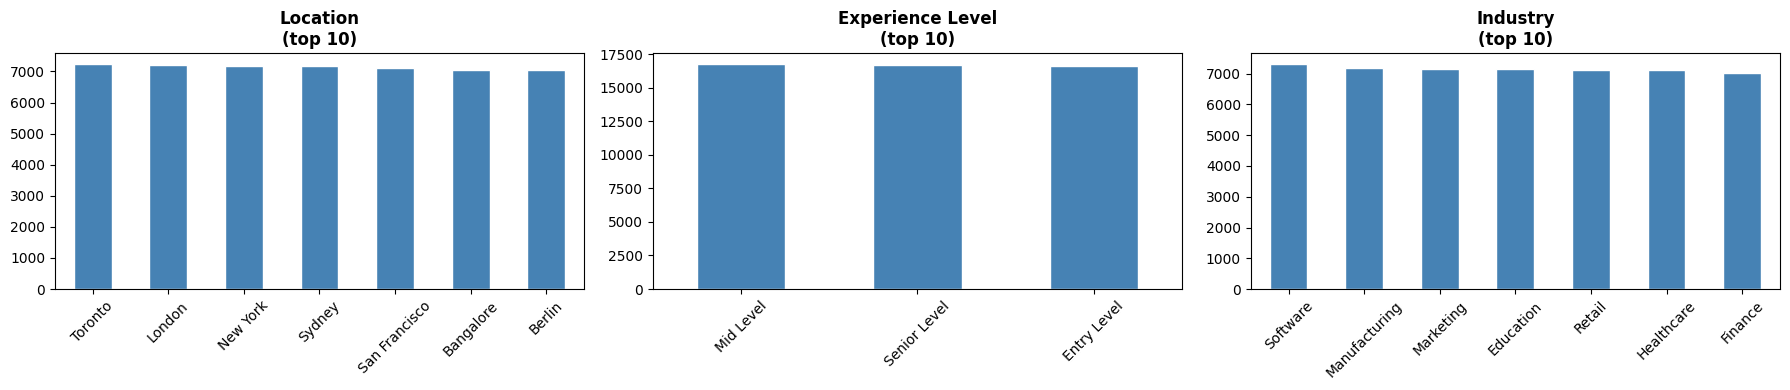

In [55]:
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).')

In [56]:
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Righe duplicate: 0 (0.00%)


___
## Correlazioni

In [57]:
print(df.columns.tolist())

['Job Title', 'Company', 'Location', 'Experience Level', 'Salary', 'Industry', 'Required Skills']


Risultati Test Chi-Quadrato tra 'Industry' e 'Experience Level':
P-value: 0.4258
Non c'è una relazione statistica significativa tra queste due variabili.


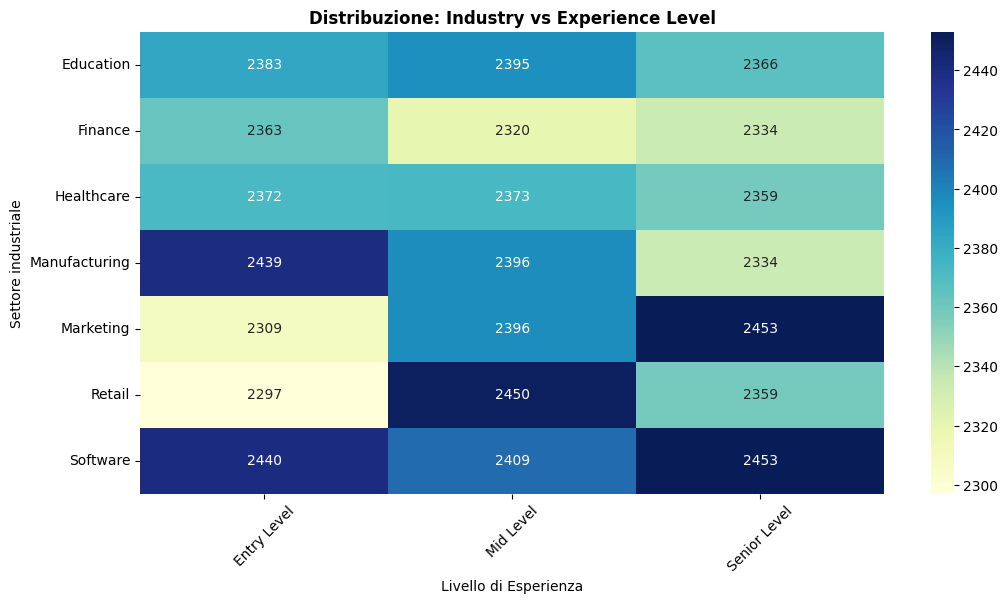

In [58]:
cat_cols = ['Industry', 'Experience Level'] 

# Tabella di Contingenza
contingency_table = pd.crosstab(df[cat_cols[0]], df[cat_cols[1]])

# Chi-Quadrato
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Risultati Test Chi-Quadrato tra '{cat_cols[0]}' e '{cat_cols[1]}':")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("Esiste una relazione significativa tra il Ruolo e il Livello di Esperienza.")
else:
    print("Non c'è una relazione statistica significativa tra queste due variabili.")

plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Distribuzione: {cat_cols[0]} vs {cat_cols[1]}', fontweight='bold')
plt.xlabel('Livello di Esperienza')
plt.ylabel('Settore industriale')
plt.xticks(rotation=45)
plt.show()

Si accetta l'ipotesi nulla: non esiste una relazione statistica significativa tra il settore industriale e il livello di esperienza dei dipendenti. La distribuzione dell'esperienza appare uniforme e indipendente dal settore di riferimento

<Axes: xlabel='Salary', ylabel='Count'>

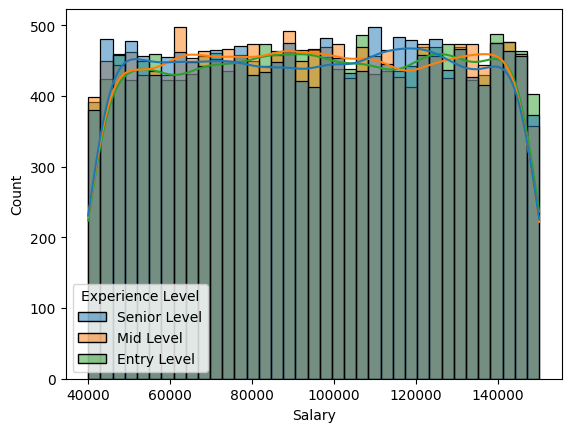

In [59]:
sns.histplot(df, x='Salary', hue='Experience Level', kde=True)

Il grafico mostra la distribuzione degli stipendi per livello di esperienza.
Tuttavia, non emerge una chiara differenza tra entry, mid e senior, poiché le distribuzioni sono molto simili e sovrapposte. Questo suggerisce che la variabile salario non è fortemente correlata con l’esperienza nel dataset.

analisi delle skills più richieste:

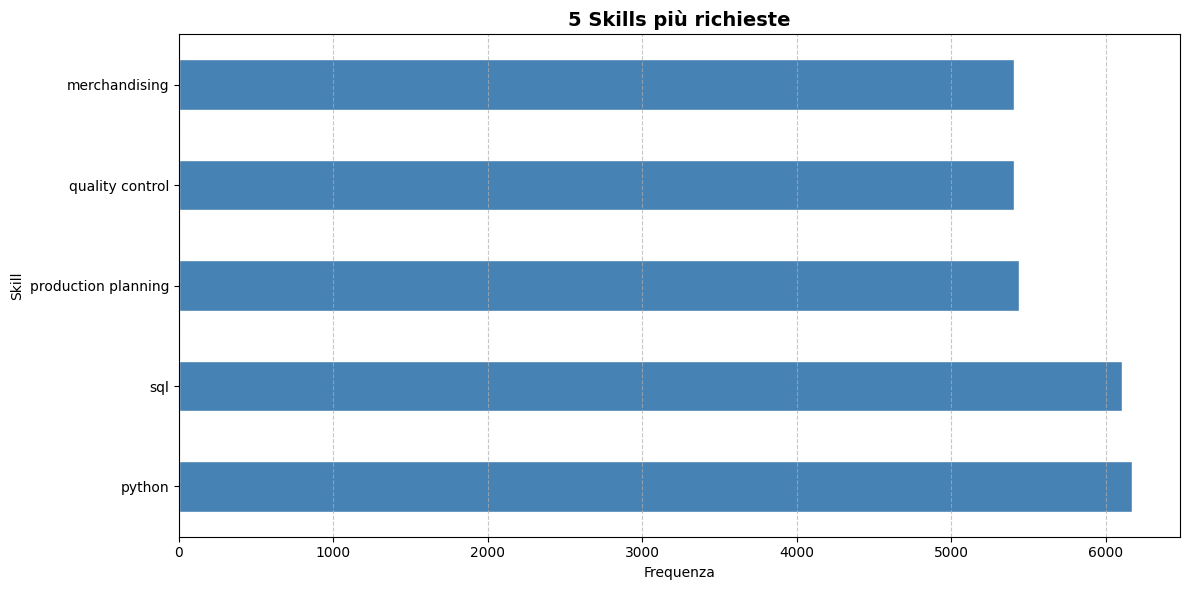

In [60]:
# skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])

# sns.barplot(data=skills_df, x='Count', y='Skill')
# plt.title('Top 10 Skills richieste')
# plt.show()

# 1. Prendiamo la colonna, dividiamo le stringhe dove c'è la virgola
# expand=True crea un DataFrame con una colonna per ogni skill
skills_split = df['Required Skills'].str.split(',', expand=True)

# 2. Trasformiamo tutto il DataFrame in una singola colonna (Series)
# stack() "impila" tutte le colonne una sotto l'altra
all_skills = skills_split.stack()

# 3. Pulizia: togliamo gli spazi bianchi extra e mettiamo tutto in minuscolo
all_skills = all_skills.str.strip().str.lower()

# 4. Contiamo le occorrenze e prendiamo le prime 10
top_5_skills = all_skills.value_counts().head(5)

# 5. Creazione del Grafico
plt.figure(figsize=(12, 6))
top_5_skills.plot(kind='barh', color='steelblue', edgecolor='white')

plt.title('5 Skills più richieste', fontsize=14, fontweight='bold')
plt.xlabel('Frequenza')
plt.ylabel('Skill')
# Inverte l'ordine per avere la più alta in cima
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


le competenze più richieste nel dataset e ho identificato SQL e Python come le skill più frequenti, seguite da competenze operative e gestionali. Questo indica una forte domanda sia per competenze tecniche che per competenze di business

media dello stipendio per gruppo:

In [61]:
df.groupby('Experience Level')['Salary'].mean()

Experience Level
Entry Level     95459.736192
Mid Level       95015.233885
Senior Level    94962.000240
Name: Salary, dtype: float64

In [62]:
#le_exp = LabelEncoder()
#le_ind = LabelEncoder()
#le_loc = LabelEncoder()

#df['Experience Level'] = le_exp.fit_transform(df['Experience Level'])
#df['Industry'] = le_ind.fit_transform(df['Industry'])
#df['Location'] = le_loc.fit_transform(df['Location'])
#print(le_exp.classes_)

In [63]:
# Target e feature
#X = df[['Salary', 'Industry', 'Location']]
#y = df['Experience Level']

In [64]:
#cat_cols = ['Industry', 'Location']
#num_cols = ['Salary']



############### No Anna aspetta non ho capito che cosa vuoi fare, ho commentato tutto perchè
############### altrimenti ho errori strani, in caso continua tu o facciamo chiamata


In [ ]:
cols_to_encode = ['Location', 'Experience Level', 'Industry']

df_encoded = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode)

df_encoded[df_encoded.columns.difference(df.columns)] = df_encoded[df_encoded.columns.difference(df.columns)].astype(int)

print(f"Forma del dataset originale: {df.shape}")
print(f"Forma dopo One-Hot Encoding: {df_encoded.shape}")
df_encoded.head()

Forma del dataset originale: (50000, 7)
Forma dopo One-Hot Encoding: (50000, 21)


,Job Title,Company,Salary,Required Skills,Location_Bangalore,Location_Berlin,Location_London,Location_New York,Location_San Francisco,Location_Sydney,...,Experience Level_Entry Level,Experience Level_Mid Level,Experience Level_Senior Level,Industry_Education,Industry_Finance,Industry_Healthcare,Industry_Manufacturing,Industry_Marketing,Industry_Retail,Industry_Software
0,Early years teacher,Richardson Ltd,87000.0,Pharmaceuticals,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
1,Counselling psychologist,"Ramos, Santiago and Stewart",50000.0,"Google Ads, SEO, Content Writing",0,0,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
2,Radio broadcast assistant,Franco Group,77000.0,"Patient Care, Nursing, Medical Research, Pharm...",0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
3,"Designer, exhibition/display",Collins Inc,90000.0,Machine Learning,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,"Psychotherapist, dance movement",Barker Group,112000.0,"Nursing, Medical Research, Pharmaceuticals",0,0,0,0,0,1,...,1,0,0,0,0,1,0,0,0,0


Standardizzazione delle variabili per fare clustering

In [ ]:
df_numeric = pd.get_dummies(df[['Location', 'Experience Level', 'Industry', 'Salary']], 
                            columns=['Location', 'Experience Level', 'Industry']).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

Dati standardizzati correttamente.


CLUSTERING

Metodo del gomito

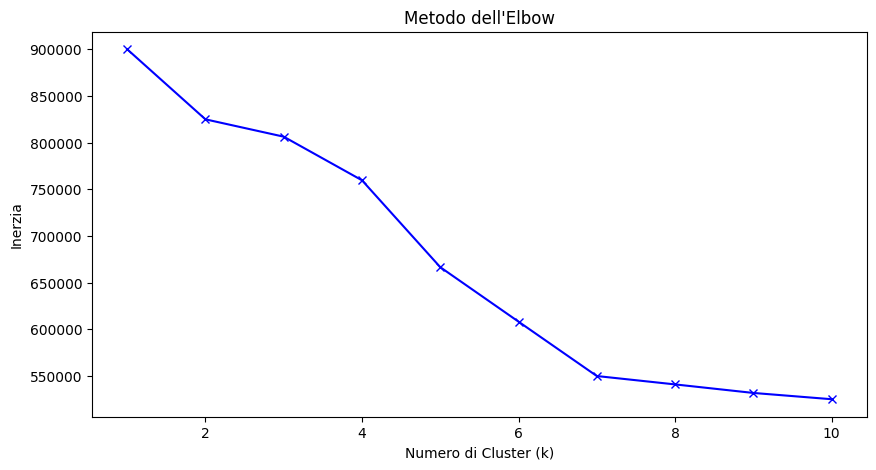

In [ ]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Inerzia')
plt.title('Metodo dell\'Elbow')
plt.show()

DBSCAN

Distribuzione cluster DBSCAN:
Cluster_DBSCAN
14     391
32     380
123    379
18     377
125    375
      ... 
72     307
140    307
31     304
144    301
111    295
Name: count, Length: 147, dtype: int64


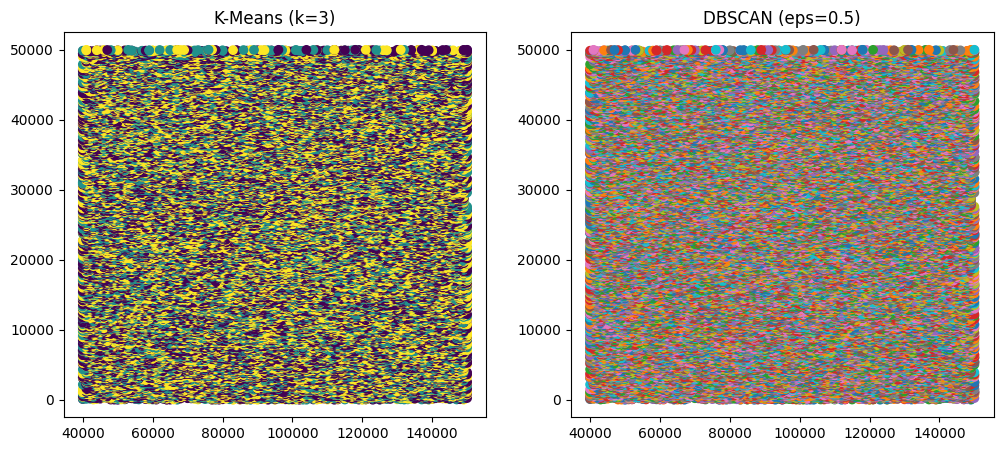

In [73]:
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Usiamo i dati standardizzati X_scaled che abbiamo creato prima
db_labels = dbscan.fit_predict(X_scaled)

# Aggiungiamo i risultati al dataframe
df['Cluster_DBSCAN'] = db_labels

# Vediamo quanti cluster ha trovato (il valore -1 indica gli OUTLIER/RUMORE)
print("Distribuzione cluster DBSCAN:")
print(df['Cluster_DBSCAN'].value_counts())

plt.figure(figsize=(12, 5))

# Grafico K-Means
plt.subplot(1, 2, 1)
plt.scatter(df['Salary'], df.index, c=df['Cluster'], cmap='viridis')
plt.title('K-Means (k=3)')

# Grafico DBSCAN
plt.subplot(1, 2, 2)
plt.scatter(df['Salary'], df.index, c=df['Cluster_DBSCAN'], cmap='tab10')
plt.title('DBSCAN (eps=0.5)')

plt.show()

PENSO DI AVER SBAGLIATO QUALCOSA AHAHAHAHHAAH